<a href="https://colab.research.google.com/github/thiagoann/UNIGOUAcademicPaper/blob/main/Application_of_Linear_Algebra_in_Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install prettytable

#MULTIPLE LINEAR REGRESSION EQUATION

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable

X = [[14.62,226,7], [15.63,220,3.375], [14.62,217.4,6.375], [15,220,6], [14.5,226.5,7.625],
    [15.25,224.1,6], [16.12,220.5,3.375], [15.13,223.5,6.125], [15.5,217.6,5], [15.13,228.5,6.625],
     [15.5,230.2,5.75], [16.12,226.5,3.75], [15.13,226.6,6.125], [15.63,225.6,5.375], [15.38,229.7,5.875],
     [14.38,234,8.875], [15.5,230,4], [14.25,224.3,8], [14.5,240.5,10.87], [14.62,223.7,7.375]]


Y = np.array([128.4,52.62,113.9,98.01,139.9,102.6,48.14,109.6,82.68,112.6,97.52, 59.06, 111.8, 89.09, 101, 171.9, 66.8, 157.1, 208.4,133.4])

'''
This will be necessary. What the line of code below does is create a
column with only ones.
This has to be done when applying linear algebra
on a multiple linear regression model. On the other hand, when using the Python libraries,
this is NOT necessary.
'''
X = np.insert(X,0,1,axis=1)

'''
THIS IS WHERE WE'LL BE APPLYING OUR ALGORITHM USING LINEAR ALGEBRA
WITH THE HELP OF PYTHON LIBRARY NUMPY.
- X_TRANSPOSE = X.T => TRANSPOSES MATRIX X
- XtX = np.dot(X_transpose,X) => FUNCTION dot() DOES THE MATRIX MULTIPLICATION
- THE SAME THING FOR XtY
- beta = np.linalg.solve(XtX,XtY) => FUNCTION SOLVE() SOLVES A MATRIX EQUATION
JUST LIKE THE ONE WE HAVE IN OUR PROBLEM AND RETURNS THE BETA VECTOR
'''
X_transpose = X.T
XtX = np.dot(X_transpose,X)
XtY = np.dot(X_transpose,Y)
beta = np.linalg.solve(XtX,XtY)
print('Our Multiple Linear Regression model equation:')
print(f'y = {round(beta[0],2)} + {round(beta[1],2)}*x1 + {round(beta[2],2)}*x2 + {round(beta[3],2)}*x3')
print('\n')

Our Multiple Linear Regression model equation:
y = 47.17 + -9.74*x1 + 0.43*x2 + 18.24*x3




#GRAPH

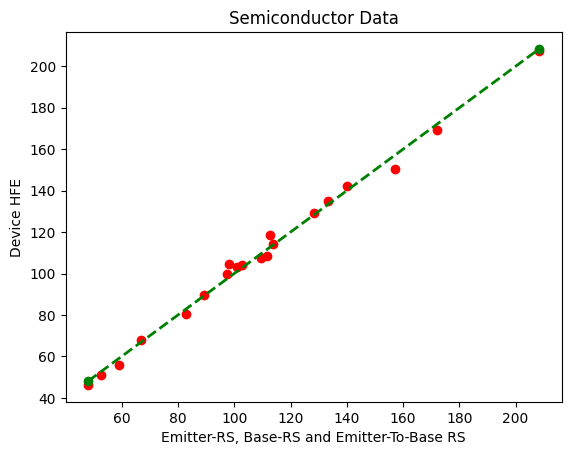

In [ ]:
'''
PLOTTING OUR GRAPH
RED = PLOTS
GREEN = FITTED LINE
'''
y_pred = np.dot(X,beta)
plt.scatter(Y, y_pred, c='red')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'go--', linewidth=2)
plt.title('Semiconductor Data')
plt.xlabel('Emitter-RS, Base-RS and Emitter-To-Base RS')
plt.ylabel('Device HFE')
plt.show()

#RESIDUALS

In [ ]:
'''
CALCULATING THE RESIDUALS AND RESHAPING THEM, SO THEY CAN BE PUT IN A TABLE
'''
residuals = Y-y_pred
residuals = residuals.reshape(-1,1)

#Showing the residuals in a table
myTable = PrettyTable(['Residuals'])
myTable.add_rows(np.round(residuals,8))
print(myTable)

SSE = np.dot(Y.T,Y) - np.dot(beta,np.dot(X.T,Y))
sigmaSquared = SSE/(len(Y)-4)
print(f'σ² = {round(sigmaSquared,3)}')
print('\n')

+-------------+
|  Residuals  |
+-------------+
| -0.90039315 |
|  1.83265673 |
| -0.31871551 |
|  -6.7838394 |
| -2.18117015 |
| -1.51601564 |
|  1.90876231 |
|  2.29305046 |
|  2.01910533 |
| -5.96711204 |
| -2.21540225 |
|  3.41999463 |
|  3.16536068 |
| -0.57066011 |
| -1.96916485 |
|  2.64163446 |
| -0.93419904 |
|  6.68821522 |
|  1.14227084 |
| -1.75437852 |
+-------------+
σ² = 12.108




#PROPERTIES OF THE LEAST SQUARE ESTIMATORS: PROPERTY #2

In [ ]:
'''
CALCULATING THE INVERSE OF MATRIX(XtX)
'''
invXtX = np.linalg.inv(np.dot(X.T,X))

print(f'C = {np.round(invXtX, decimals=4)}')

print('\n')

print('MATRIX OF COVARIANCES:')
cov = sigmaSquared*np.linalg.inv(np.dot(X.T,X))
print(f'cov = {np.round(cov, decimals=4)}')
print('\n')

'''
Calculating the variances
'''
print('VARIANCES:')
for i in range(len(invXtX)):
  V = sigmaSquared*invXtX[i][i]
  print(V)

print('\n')

'''
Calculating the covariances
'''
print('COVARIANCES:')
for i in range(len(invXtX)):
  for j in range(len(invXtX)):
    covariances = sigmaSquared*invXtX[i][j]
  print(covariances)

print('\n')


C = [[ 2.030363e+02 -9.744100e+00 -1.833000e-01 -2.303600e+00]
 [-9.744100e+00  1.125600e+00 -4.230000e-02  3.662000e-01]
 [-1.833000e-01 -4.230000e-02  4.100000e-03 -1.820000e-02]
 [-2.303600e+00  3.662000e-01 -1.820000e-02  1.421000e-01]]


MATRIX OF COVARIANCES:
cov = [[ 2.4583228e+03 -1.1798000e+02 -2.2191000e+00 -2.7891400e+01]
 [-1.1798000e+02  1.3628100e+01 -5.1170000e-01  4.4333000e+00]
 [-2.2191000e+00 -5.1170000e-01  5.0100000e-02 -2.2050000e-01]
 [-2.7891400e+01  4.4333000e+00 -2.2050000e-01  1.7208000e+00]]


VARIANCES:
2458.322766994938
13.628094577044306
0.05014616205242177
1.720823730154093


COVARIANCES:
-27.891379682482565
4.433336861724476
-0.22054710022723248
1.720823730154093




#PREDICTIONS

In [ ]:
#PREDICTIONS
y_pred = y_pred.reshape(-1,1)

#Showing the predictions in a table
myTable = PrettyTable(['Predictions'])
myTable.add_rows(np.round(y_pred,8))
print(myTable)

print('\n')

'''Predict y if x1 = 14.5, x2 = 220 and x3 = 5 '''
x1 =14.5
x2=220
x3=5
print(f'For x1 = {x1}, x2 = {x2} and x3 = {x3}, y = {np.round(beta[0]+beta[1]*x1 + beta[2]*x2 + beta[3]*x3, 8) }')

print('\n')

+--------------+
| Predictions  |
+--------------+
| 129.30039315 |
| 50.78734327  |
| 114.21871551 |
| 104.7938394  |
| 142.08117015 |
| 104.11601564 |
| 46.23123769  |
| 107.30694954 |
| 80.66089467  |
| 118.56711204 |
| 99.73540225  |
| 55.64000537  |
| 108.63463932 |
| 89.66066011  |
| 102.96916485 |
| 169.25836554 |
| 67.73419904  |
| 150.41178478 |
| 207.25772916 |
| 135.15437852 |
+--------------+


For x1 = 14.5, x2 = 220 and x3 = 5, y = 91.42398577




#COEFFICIENT OF DETERMINATION (R²)

In [ ]:
'''We'll now calculate the coefficient of regression, the R², which, according to the paper,
measures how adequate our model is.'''

'''
CALCULATING R²
'''
averageY = np.mean(Y)
SST = 0

for i in range(len(Y)):
  SST += (Y[i]-averageY)**2

print(f'R² = {round(1-(SSE/SST),3)*100}%')

R² = 99.4%
